# Creation of simulated Environments with fixed proportions / Data Viz for analysis.


### [ESP] Creación de entornos simulados.



#### 1. Import the necessary libraries.



[ESP] Importar las librerías necesarias.

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Create some variables that will be modified later.

[ESP] Creamos algunas variables que después modificaremos.


In [ ]:
hostnames = []
dataset = []
df = None

#### 3. Function to generate hostnames based on specific parameters; the numbers indicate the proportion of each element we intend to create. Later we will concatenate some functions to generate the environments.



[ESP] Creamos una función para generar los hostnames en base a unos parametros específicos, los números indican la proporción de cada elemento que pretendemos crear.

In [ ]:
def set_hostnames(number_of_hosts: int) -> None:
    sistema_operativo = ['L']*40 + ['S']*30 + ['A']*20 + ['H']*10 # Linux: 40% | Solaris: 30% | AIX: 20% | HP-UX: 10%
    entorno = ['D']*10 + ['I']*10 + ['T']*25 + ['S']*25 + ['P']*30 # Development: 10% | Integration: 10% | Testing: 25% | Staging: 25% | Production: 30%
    pais = ['NOR']*6 + ['FRA']*9 + ['ITA']*16 + ['ESP']*16 + ['DEU']*23 + ['IRE']*30 # Norway: 6% | France: 9% | Italy: 16% | Spain: 16% | Germany: 23% | Ireland: 30%
    grupo_alpha = []

    for i in range(number_of_hosts):
        hostname = (random.choice(sistema_operativo) + random.choice(entorno) + random.choice(pais))
        grupo_alpha.append(hostname)
        hostname += str(grupo_alpha.count(hostname)).zfill(3)
        hostnames.append(hostname)


#### 4. Function to obtain the OS name.



[ESP] Creamos una función para obtener el nombre del SO.

In [ ]:
def get_os(hostname: str) -> str:
    if hostname.startswith('L'):
        return 'Linux'
    elif hostname.startswith('S'):
        return 'Solaris'
    elif hostname.startswith('A'):
        return 'AIX'
    elif hostname.startswith('H'):
        return 'HP-UX'
    else:
        return 'Unknown'

#### 5. Function to obtain the environment name.

[ESP] Creamos una función para obtener el nombre del entorno.

In [ ]:
def get_environment(hostname: str) -> str:
    environment = hostname[1]
    if environment == 'D':
        return 'Development'
    elif environment == 'I':
        return 'Integration'
    elif environment == 'T':
        return 'Testing'
    elif environment == 'S':
        return 'Staging'
    elif environment == 'P':
        return 'Production'
    else:
        return 'Unknown'

#### 6. Function to obtain the country name.

[ESP] Función para obtener el nombre del país.

In [ ]:
def get_country(hostname: str) -> str:
    country = hostname[2:5]
    if country == 'NOR':
        return 'Norway'
    elif country == 'FRA':
        return 'France'
    elif country == 'ITA':
        return 'Italy'
    elif country == 'ESP':
        return 'Spain'
    elif country == 'DEU':
        return 'Germany'
    elif country == 'IRE':
        return 'Ireland'
    else:
        return 'Unknown'

#### 7. Function to generate the DataFrame.

[ESP] Función para generar el DataFrame.

In [ ]:
def set_dataframe(x:int) -> None:
    global df

    set_hostnames(x)

    for i in hostnames:
        dataset.append({
            'hostname': i,
            'os': get_os(i),
            'environment': get_environment(i),
            'country': get_country(i),
            'node' : int(i[-3:])
        })

    df = pd.DataFrame(dataset)

#### 8. We create the DataFrame and verify that the outputs are correct.



[ESP] Creamos el DataFrame y verificamos que los outputs sean correctos.

In [ ]:
set_dataframe(1500)
df

,hostname,os,environment,country,node
0,HTDEU001,HP-UX,Testing,Germany,1
1,ASIRE001,AIX,Staging,Ireland,1
2,SPDEU001,Solaris,Production,Germany,1
3,HPDEU001,HP-UX,Production,Germany,1
4,HPIRE001,HP-UX,Production,Ireland,1
...,...,...,...,...,...
1495,LPDEU049,Linux,Production,Germany,49
1496,LTDEU038,Linux,Testing,Germany,38
1497,LTFRA008,Linux,Testing,France,8
1498,LPITA036,Linux,Production,Italy,36


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   hostname     1500 non-null   object
 1   os           1500 non-null   object
 2   environment  1500 non-null   object
 3   country      1500 non-null   object
 4   node         1500 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 58.7+ KB


In [ ]:
df.to_csv(
    'hosts.csv',
    header = True,
    index = False
)

df_hosts = pd.read_csv('hosts.csv')
df_hosts

,hostname,os,environment,country,node
0,HTDEU001,HP-UX,Testing,Germany,1
1,ASIRE001,AIX,Staging,Ireland,1
2,SPDEU001,Solaris,Production,Germany,1
3,HPDEU001,HP-UX,Production,Germany,1
4,HPIRE001,HP-UX,Production,Ireland,1
...,...,...,...,...,...
1495,LPDEU049,Linux,Production,Germany,49
1496,LTDEU038,Linux,Testing,Germany,38
1497,LTFRA008,Linux,Testing,France,8
1498,LPITA036,Linux,Production,Italy,36


#### 9. We generate a single chart, grouping the environments for each country.



[ESP] Generamos un único gráfico, agrupando para cada país (country) los entornos (environment).

<Axes: xlabel='country'>

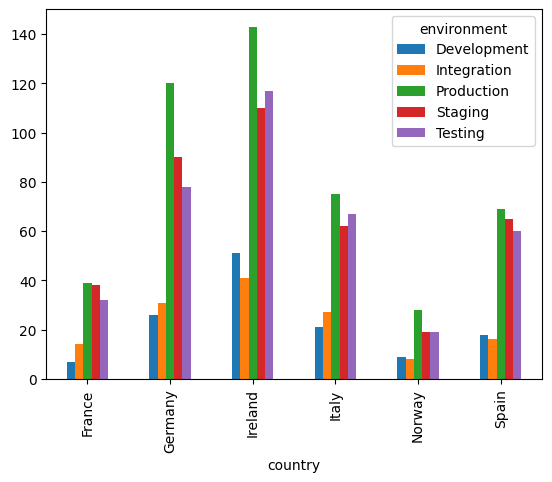

In [ ]:
g = df.groupby(['country', 'environment']).size()
g.unstack().plot(kind='bar')

#### 10. We create a figure with 4 charts in a 2-row by 2-column grid to visualize the proportion of the created environments.



[ESP] Creamos una figura con 4 gráficos en una malla de 2 filas y 2 columna para visualizar la proporción de los entornos creados.


/tmp/ipykernel_8946/3215474732.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hosts_by_country.values, y=hosts_by_country.index, ax=axs[1,0], palette=sns.color_palette('viridis', len(hosts_by_country)))


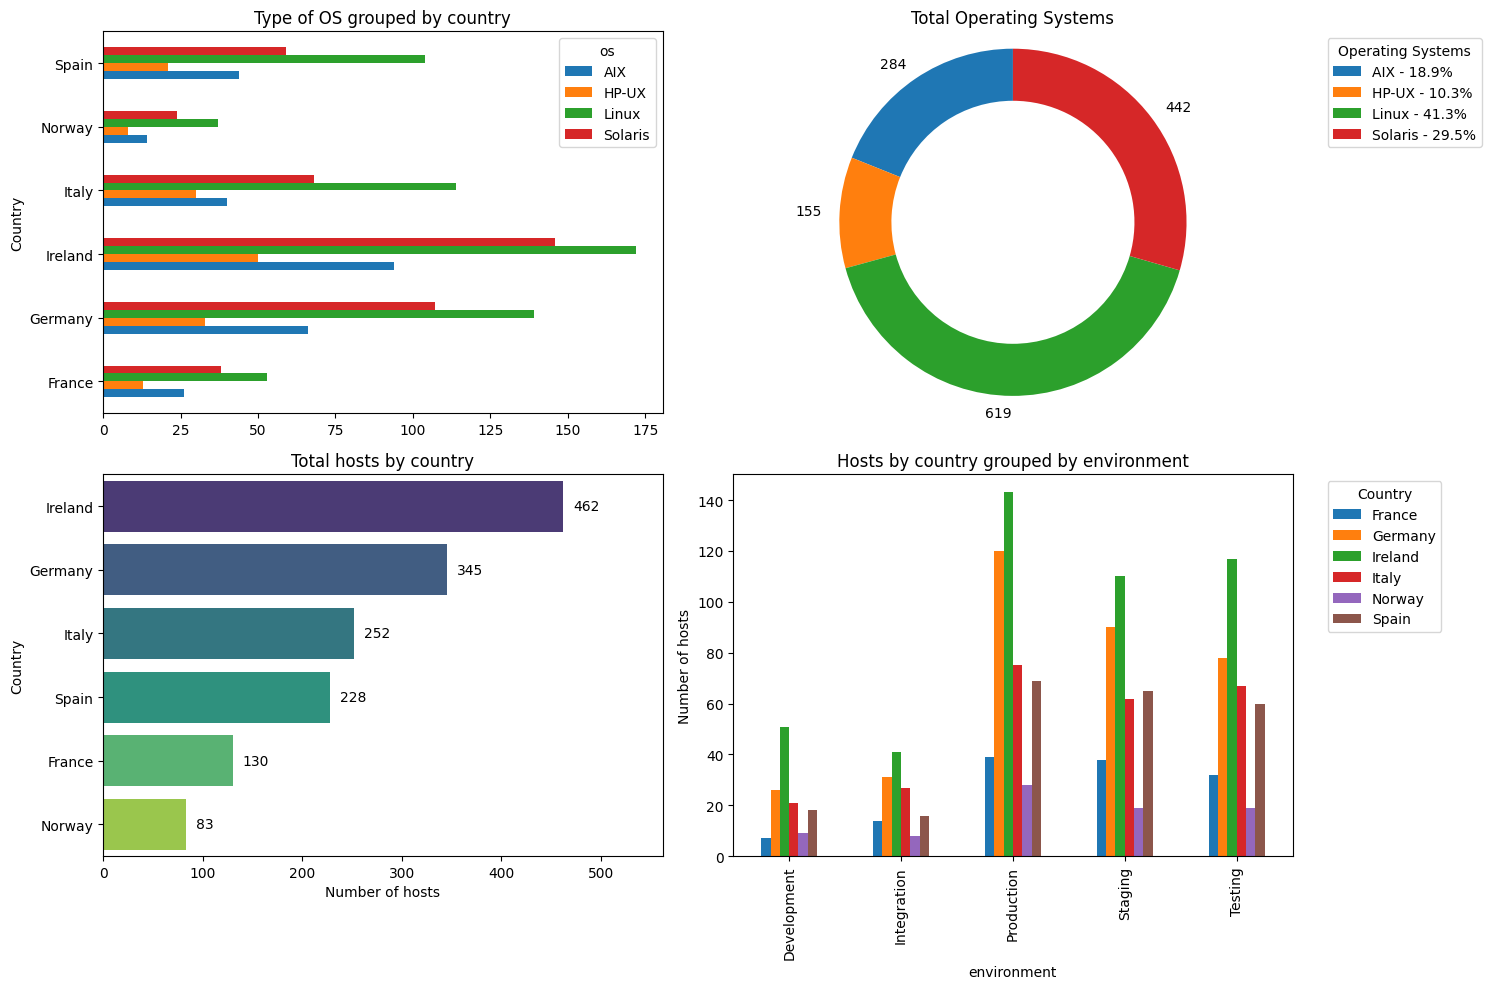

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Primer gráfico

os_by_country = df.groupby(['country', 'os']).size().unstack()
os_by_country.plot(kind='barh', ax=axs[0,0])
axs[0,0].set_title('Type of OS grouped by country')
axs[0,0].set_ylabel('Country')

# Segundo gráfico

total_os = df.groupby('os').size()

porcentages = (total_os / total_os.sum() * 100).round(1)

pie_labels = [f'{count}' for count in total_os.values]

legend_labels = [f'{os_name} - {percent:.1f}%' for os_name, percent in zip(total_os.index, porcentages)]

wedges, texts = axs[0,1].pie(total_os.values, labels=pie_labels, startangle=90, wedgeprops=dict(width=0.3))
axs[0,1].set_title('Total Operating Systems')
axs[0,1].axis('equal')
axs[0,1].legend(wedges, legend_labels, title="Operating Systems", loc="upper left", bbox_to_anchor=(1.05, 1))

# Tercer gráfico

hosts_by_country = df['country'].value_counts()
max_hosts_count = hosts_by_country.max()

sns.barplot(x=hosts_by_country.values, y=hosts_by_country.index, ax=axs[1,0], palette=sns.color_palette('viridis', len(hosts_by_country)))
axs[1,0].set_title('Total hosts by country')
axs[1,0].set_xlabel('Number of hosts')
axs[1,0].set_ylabel('Country')
axs[1,0].set_xlim(right=max_hosts_count + 100)

for index, value in enumerate(hosts_by_country.values):
    axs[1,0].text(value + 10, index, str(value), va='center')

# Cuarto gráfico
hosts_country_env = df.groupby(['country', 'environment']).size().unstack(0)
hosts_country_env.plot(kind='bar', ax=axs[1,1])
axs[1,1].set_title('Hosts by country grouped by environment')
axs[1,1].set_ylabel('Number of hosts')
axs[1,1].legend(title="Country", loc='upper left', bbox_to_anchor=(1.05, 1))

fig.tight_layout()